# Annual thirstwave metrics (growing season only, event-based)

## Import libraries and define helper functions

In [1]:
import scienceplots
from pathlib import Path
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Circle

import sys
sys.path.insert(0, '../') # Trick to import code from parent library
import cmip6_archive as ca

In [2]:
def global_weighted_mean(da: xr.DataArray):
    "Calculates global spatial mean using cosine weighting."
    weights = np.cos(np.deg2rad(da.lat))   
    return da.weighted(weights).mean(("lon", "lat"))

## Load thirstwave metrics during the growing season

In [3]:
models = ca.MODELS
experiments = ca.EXPERIMENTS
combinations = [(model, exp) for model in models for exp in experiments]

# Load back all results from the .nc files
all_results = {model: {} for model in ca.MODELS}
n_loaded = 0
for (model, exp) in combinations:
    ds = ca.THIRSTWAVE_METRICS_GS_ARCHIVE.open(model=model, exp=exp)
    if ds is not None:
        all_results[model][exp] = ds
        n_loaded += 1

print(f"✅ Loaded data from {n_loaded} model x experiment combinations")

✅ Loaded data from 40 model x experiment combinations


## Compute global mean intensity, frequency and duration

In [4]:
intensity_all = {exp: {} for exp in experiments}
frequency_all = {exp: {} for exp in experiments}
duration_all = {exp: {} for exp in experiments}
rad_frac_all = {exp: {} for exp in experiments}
for exp in experiments:
    for model in models:
        try:
            ds = all_results.get(model).get(exp)
            land_area_fraction = ca.LAND_MASKS_ARCHIVE.open(model=model, exp='piControl')['sftlf']
            if ds is None or land_area_fraction is None:
                print(f"[{model} / {exp}] ERROR loading")
                continue
            
        except Exception as e:
            print(f"[{model} / {exp}] ERROR: {e}")

        # Mask out grid cells with < 5% land
        ds_masked = ds.where(land_area_fraction.values >= 5)

        # Calculate global mean intensity, frequency and duraton and store
        intensity_all[exp][model] = global_weighted_mean(ds_masked.intensity).compute()
        frequency_all[exp][model] = global_weighted_mean(ds_masked.event_count).compute()
        duration_all[exp][model] = global_weighted_mean(ds_masked.mean_duration).compute()
        rad_frac_all[exp][model] = global_weighted_mean(ds_masked.rad_frac_tw).compute()

    ints = [ds_masked for m, ds_masked in intensity_all[exp].items() if ds_masked is not np.nan]
    freqs = [ds_masked for m, ds_masked in frequency_all[exp].items() if ds_masked is not np.nan]
    durs = [ds_masked for m, ds_masked in duration_all[exp].items() if ds_masked is not np.nan]
    rad_fracs = [ds_masked for m, ds_masked in rad_frac_all[exp].items() if ds_masked is not np.nan]

    # Find multi-model mean of frequency, intensity and duration
    intensity_all[exp]["mean"] = xr.concat(ints, dim="model").mean(dim="model")
    frequency_all[exp]["mean"] = xr.concat(freqs, dim="model").mean(dim="model")
    duration_all[exp]["mean"] = xr.concat(durs, dim="model").mean(dim="model")
    rad_frac_all[exp]["mean"] = xr.concat(rad_fracs, dim="model").mean(dim="model")

    # Inter-model spread: standard deviation across models
    intensity_all[exp]["std"] = xr.concat(ints, dim="model").std(dim="model")
    frequency_all[exp]["std"] = xr.concat(freqs, dim="model").std(dim="model")
    duration_all[exp]["std"] = xr.concat(durs, dim="model").std(dim="model")
    rad_frac_all[exp]["std"] = xr.concat(rad_fracs, dim="model").std(dim="model")

# Load ERA5 metrics

In [5]:
# Open ERA5 reference path
era5_path = "/work5/ERA5_daily_landgrid_only/global/compressed_sfc_fc_daily_198001.nc4"
era5 = xr.open_dataset(era5_path)

# Add ERA5 lat/lon data to thirstwave metrcs
file = "/work7/IPCS_extreme/Plot_main_text_Figure/outcomes/thirstwave_metrics_growing_season_new.nc"
tw_features = xr.open_dataset(file)

tw_features = tw_features.assign_coords(
    lat=("lgrid", era5["lat"].values),
    lon=("lgrid", era5["lon"].values),
)

# Take global area-weighted mean
weights = np.cos(np.deg2rad(tw_features.lat))
tw_features_weighed = tw_features.weighted(weights)
era5_weighted_mean = tw_features_weighed.mean('lgrid')
era5_weighted_mean

<xarray.Dataset> Size: 2kB
Dimensions:          (year: 43)
Coordinates:
  * year             (year) int64 344B 1981 1982 1983 1984 ... 2021 2022 2023
Data variables:
    intensity        (year) float32 172B 0.515 0.5294 0.5458 ... 0.6074 0.6093
    event_count      (year) float32 172B 1.412 1.127 1.616 ... 3.611 3.603 4.264
    mean_duration    (year) float32 172B 3.651 3.585 3.749 ... 4.005 4.159 4.228
    true_days        (year) float32 172B 5.247 4.129 6.204 ... 14.75 15.24 18.54
    gs_days          (year) float32 172B 213.4 213.4 213.4 ... 213.4 213.4 213.4
    event_freq_100d  (year) float32 172B 0.6616 0.528 0.7576 ... 1.688 1.998
    day_fraction     (year) float32 172B 0.02459 0.01935 ... 0.07138 0.08688
    rad_frac_tw      (year) float32 172B 0.3664 0.324 0.3461 ... 0.3709 0.4035

## Plot

In [14]:
# Line styling for each experiment (color + linewidth), shared across all panels
EXPERIMENT_STYLE = {
    "ssp126": {"color": "#f4bbba", "linewidth": 0.5, "zorder": 1, "label": "SSP1-2.6"},
    "historical": {"color": "#c4c4c4", "linewidth": 0.5, "zorder": 0, "label": "Historical"},
    "ssp245": {"color": "#ed8e8c", "linewidth": 0.5, "zorder": 2, "label": "SSP2-4.5"},
    "era5": {"color": "blue", "linewidth": 0.8, "zorder": 5, "label": "ERA5"},
    "ssp370": {"color": "#cb4d4e", "linewidth": 0.5, "zorder": 3, "label": "SSP3-7.0"},
    "ssp585": {"color": "#a4181c", "linewidth": 0.5, "zorder": 4, "label": "SSP5-8.5"},
}

# Year at which the historical experiment ends and the SSPs begin
TRANSITION_YEAR = 2014

# Fixed x-axis range for the combined figure
XLIM = (1980, 2100)

  ✓ annual_thirstwave_metrics_growing_season.png
  ✓ annual_thirstwave_metrics_growing_season.pdf


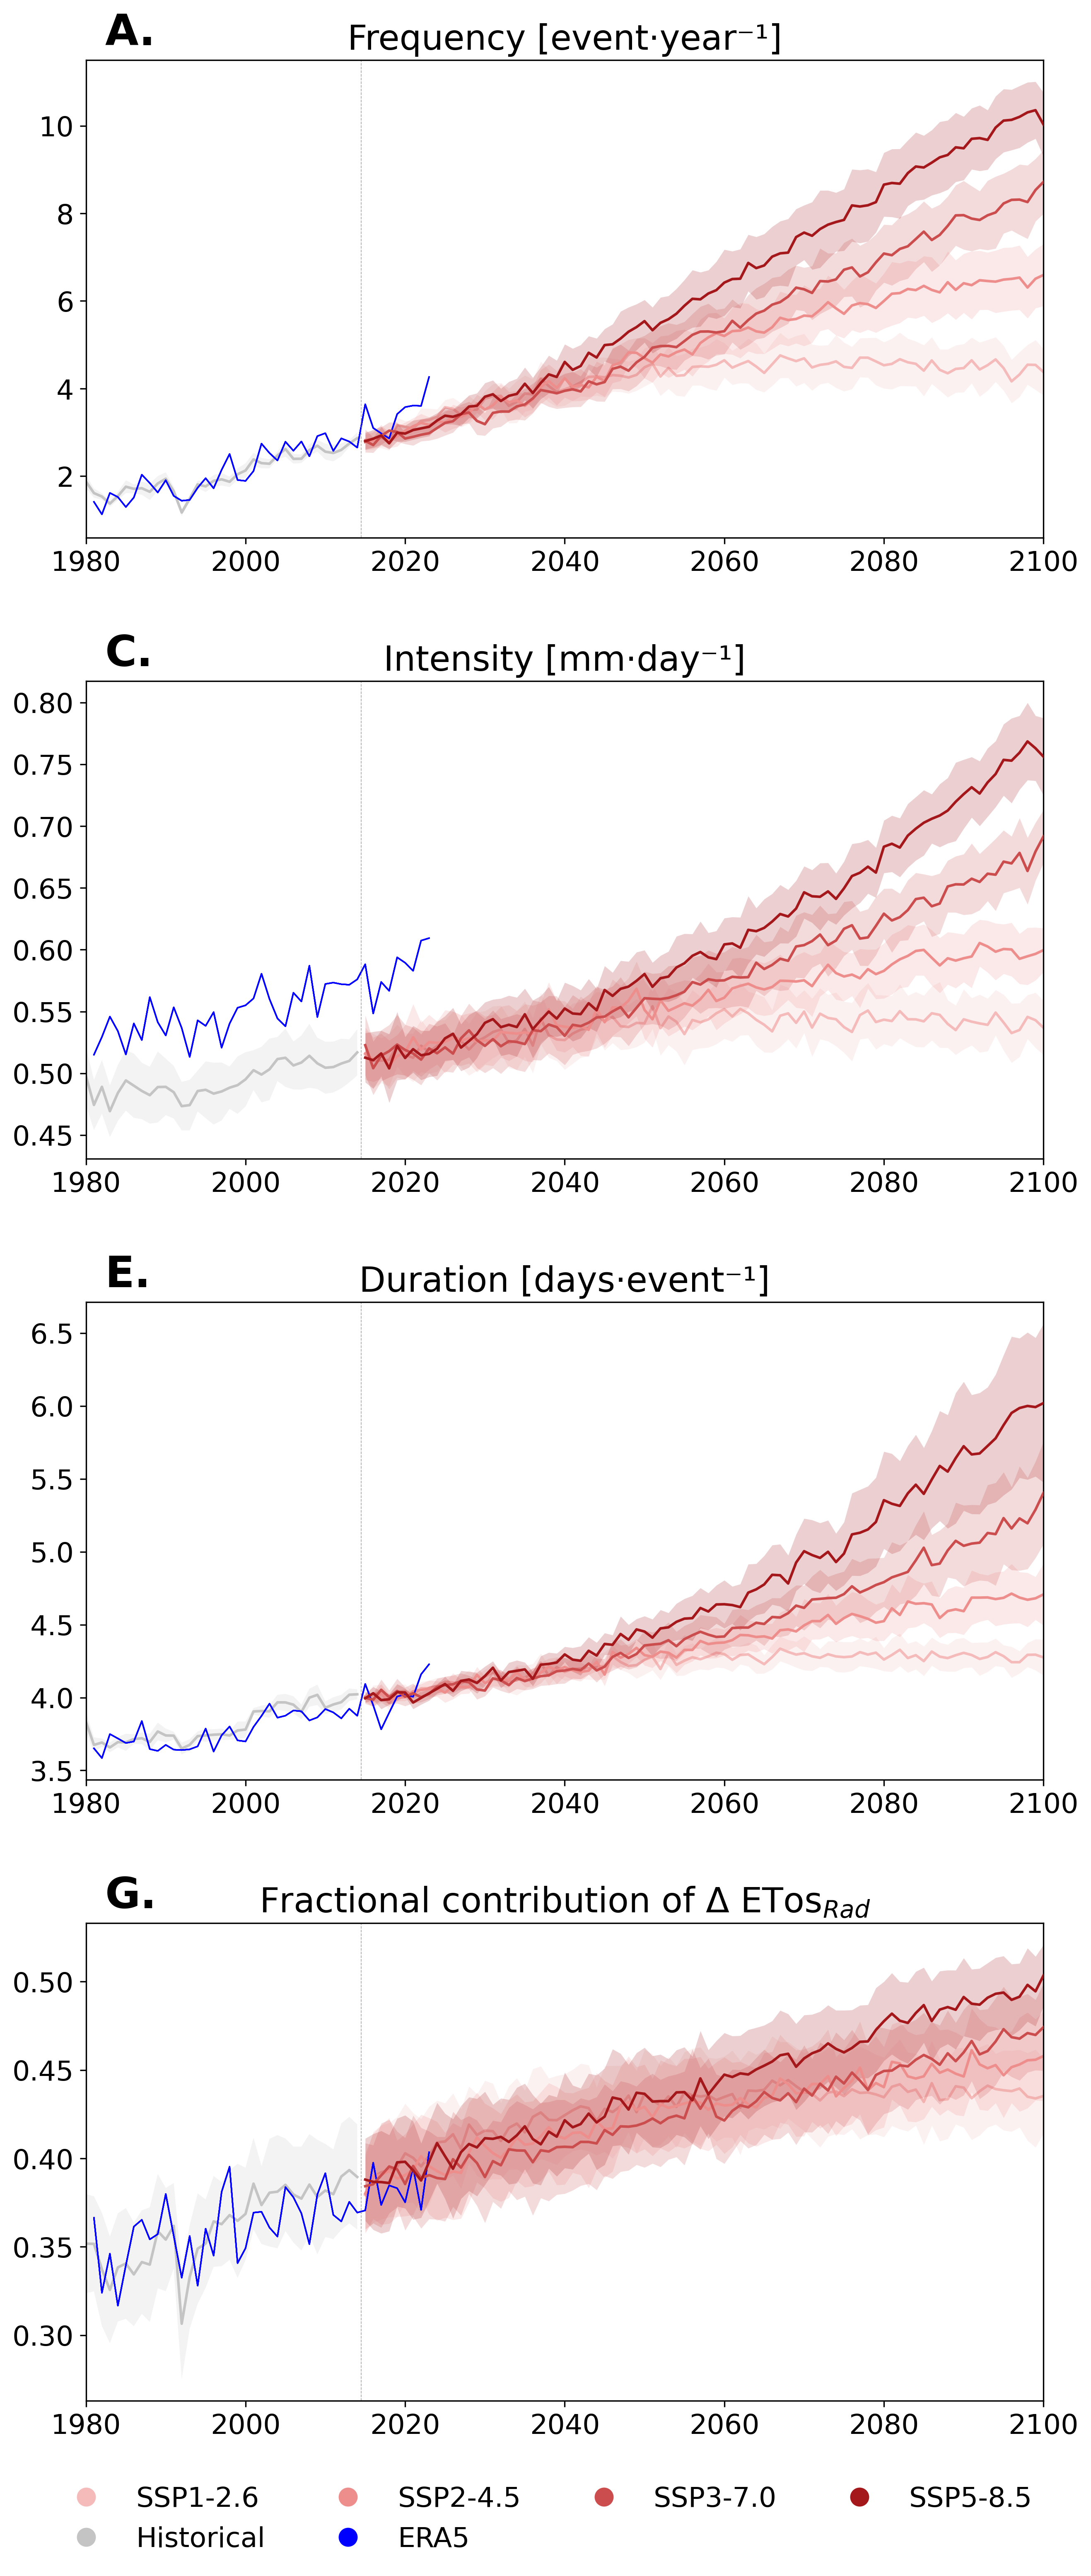

In [28]:

#  4x1 subplot
fig, axes = plt.subplots(
    4, 1,
    figsize=(9, 25 * 4 / 5),
)

# Style adjustments
plot_params = {
    "figure.dpi": 300,
    "font.size": 14,
    "axes.labelsize": "medium",
    "axes.titlesize": 20,        # matches ax.set_title(..., fontsize=20) in end_of_century_maps_anom.py
    "figure.titlesize": "large",
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "legend.fontsize": 16,
}
plt.rcParams.update(plot_params)

for exp in experiments:
    style = EXPERIMENT_STYLE[exp]

    # Plot mean of the 8 models with a thicker line
    frequency_all[exp]["mean"].plot(ax=axes[0], color=style["color"], linewidth=style["linewidth"]*3, zorder=style["zorder"]) 
    intensity_all[exp]["mean"].plot(ax=axes[1], color=style["color"], linewidth=style["linewidth"]*3, zorder=style["zorder"])
    duration_all[exp]["mean"].plot(ax=axes[2], color=style["color"], linewidth=style["linewidth"]*3, zorder=style["zorder"])
    rad_frac_all[exp]["mean"].plot(ax=axes[3], color=style["color"], linewidth=style["linewidth"]*3, zorder=style["zorder"])

    # Shading represents inter-model spread (mean +- 0.5 std)
    x = intensity_all[exp]["mean"].year

    frequency_upper = frequency_all[exp]["mean"] + frequency_all[exp]["std"]*0.5
    frequency_lower = frequency_all[exp]["mean"] - frequency_all[exp]["std"]*0.5
    axes[0].fill_between(x, frequency_lower.values, frequency_upper.values, color=style["color"], alpha=0.2, linewidth=0)

    intensity_upper = intensity_all[exp]["mean"] + intensity_all[exp]["std"]*0.5
    intensity_lower = intensity_all[exp]["mean"] - intensity_all[exp]["std"]*0.5
    axes[1].fill_between(x, intensity_lower.values, intensity_upper.values, color=style["color"], alpha=0.2, linewidth=0)

    duration_upper = duration_all[exp]["mean"] + duration_all[exp]["std"]*0.5
    duration_lower = duration_all[exp]["mean"] - duration_all[exp]["std"]*0.5
    axes[2].fill_between(x, duration_lower.values, duration_upper.values, color=style["color"], alpha=0.2, linewidth=0)

    rad_frac_upper = rad_frac_all[exp]["mean"] + rad_frac_all[exp]["std"]*0.5
    rad_frac_lower = rad_frac_all[exp]["mean"] - rad_frac_all[exp]["std"]*0.5
    axes[3].fill_between(x, rad_frac_lower.values, rad_frac_upper.values, color=style["color"], alpha=0.2, linewidth=0)

    # Add ERA5 data in blue
    style = EXPERIMENT_STYLE["era5"]
    era5_weighted_mean.event_count.plot(color=style["color"], linewidth=style["linewidth"], ax=axes[0])
    era5_weighted_mean.intensity.plot(color=style["color"], linewidth=style["linewidth"], ax=axes[1])
    era5_weighted_mean.mean_duration.plot(color=style["color"], linewidth=style["linewidth"], ax=axes[2])
    era5_weighted_mean.rad_frac_tw.plot(color=style["color"], linewidth=style["linewidth"], ax=axes[3])


labels = ["A.", "C.", "E.", "G."]
for ax, label in zip(axes, labels):
    # Add label to panel
    ax.text(
        0.02, 1.10, label,
        transform=ax.transAxes,
        fontsize=25,
        fontweight='bold',
        va='top',
        ha='left'
    )
    ax.axvline(TRANSITION_YEAR+0.5, color="grey", linestyle="--", linewidth=0.4, alpha=0.7) # Dashed grey vertical line marking the end of the historical exp / start of the SSPs
    ax.set_xlim(*XLIM) # X axis from 1980 to 2100
    ax.set_xlabel('')
    ax.set_ylabel('')

axes[0].set_title("Frequency [event·year⁻¹]")
axes[1].set_title("Intensity [mm·day⁻¹]")
axes[2].set_title("Duration [days·event⁻¹]")
axes[3].set_title(r"Fractional contribution of $\Delta$ ETos$_{Rad}$")

# Shared legend for the whole figure
legend_handles = [
    Line2D([0], [0], color=style["color"], label=style['label'],
           marker='o', linestyle='', markersize=10) # Make marker a little circle
    for exp, style in EXPERIMENT_STYLE.items()
]
fig.legend(handles=legend_handles, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.04), frameon=False)

fig.tight_layout(rect=(0.0, 0.005, 1, 1))
fig.subplots_adjust(wspace=0.0, hspace=0.3)

# Save in current directory as png and pdf
for ext in ["png", "pdf"]:
    filename = f"annual_thirstwave_metrics_growing_season.{ext}"
    fig.savefig(filename, dpi=500, bbox_inches="tight", pad_inches=0.3)
    print(f"  ✓ {filename}")

plt.show()